# Fundamentals of Statistics

Before starting with the details of machine learning, let us first recap some fundamental concepts of statistics. These are the terms that you will use again and again if you stick with the business of machine learning. Machine learning is a science, but it is also a form of painting: statistics and mathematics are like the paint and the brush strokes.

In this lecture we will go through a small but important chain of ideas:

1. **Probability distributions**: how we assign probabilities to possible outcomes.
2. **Binomial distribution**: the simplest repeated-trial model, useful for heads/tails, pass/fail, signal/background counting, etc.
3. **Gaussian distribution**: the familiar bell curve that appears in measurement errors, detector resolutions, averages, and many approximation arguments.
4. **Likelihood**: how the same formula becomes a function of the unknown parameter after the data are observed.
5. **Histograms**: how data give us an empirical picture of a distribution.
6. **Surprise, Shannon entropy, and Gini index**: three related ways of quantifying uncertainty or impurity.

## <span style="color:maroon"> Probability distribution function </span>

Let us first jump into the definitions of a probability distribution functions (PDF). A **random variable** is a mathematical object that assigns a number to the outcome of an experiment. For example:

- the number of heads in 10 coin tosses,
- the transverse momentum of a particle in a detector,
- the number of events passing a selection cut,
- the energy recorded in a calorimeter cell.

The probability distribution tells us how probability is spread over the possible values of the random variable. They come in two flavours **discrete** and **continuous**. To be *worthy* of being a probability distribution both of them have to obey some properties.


> ### <span style="color:blue"> Discrete probability distribution </span>
>
> The probability distribution of a discrete random variable is a list of probabilities associated with each of its possible outcomes. It is also sometimes called the probability mass function (PMF). Suppose a random variable $X$ may take $k$ different values, with the probability that $X = x_{i}$ defined to be $P(X = x_{i}) = p_{i}$. Then the probabilities $p_{i}$ must satisfy the following:
>
> 1: 0 < $p_{i}$ < 1 for each $i$
>
> 2: $p_{1} + p_{2} + ... + p_{k} = 1$.


#### Binomial distribution

This is the distribution where only two outcomes are possible, *success* and *failure* with probabilities $p$ and $1-p$. Then the probability of $k$ successes in $n$ trials is

$$
P(X = k) = \binom{n}{k} p^k (1 - p)^{n - k} ; \quad \text{where } \binom{n}{k}=\frac{n!} {(n-k)!}
$$




In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, binom # For binomial distribution alreayd defined
from math import comb
import ipywidgets as widgets
from IPython.display import display

def binomial_pmf(k, n, p):
    return comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

def plot_binomial(n, p, k_highlight):
    k = np.arange(0, n + 1)  # Possible number of successes
    probs = np.array([binomial_pmf(ki, n, p) for ki in k])  # PMF values

    plt.figure(figsize=(10, 6))
    markerline, stemlines, baseline = plt.stem(k, probs)
    plt.setp(markerline, color='b', label="PMF")
    plt.setp(stemlines, color='b')

    # Highlight one point in red
    if 0 <= k_highlight <= n:
        plt.plot(k_highlight, binom.pmf(k_highlight, n, p), 'ro', label=f"P(X={k_highlight})")

    plt.title(f"Binomial Distribution PMF (n={n}, p={p})")
    plt.xlabel("Number of Successes (k)")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True)
    plt.show()

widgets.interact(
    plot_binomial,
    n=widgets.IntSlider(value=10, min=1, max=50, step=1, description='Trials (n)'),
    p=widgets.FloatSlider(value=0.5, min=0.01, max=1.0, step=0.01, description='Success Prob (p)'),
    k_highlight=widgets.IntSlider(value=5, min=0, max=50, step=1, description='k Highlight')
    )


x = binomial_pmf(30,0.5,10)
print(x)

interactive(children=(IntSlider(value=10, description='Trials (n)', max=50, min=1), FloatSlider(value=0.5, des…

0.02798160072416067


### ❓ Exercise
**Q1:** For a binomial distribution with $n = 30$, and success probability of $p=0.5$, what is the probability of getting $10$ successes?

### ❓ Exercise
**Q2:** When is the binomial distribution most symmetric?


> ### <span style="color:blue"> Continuous probability distribution </span>
>
> As the name suggests in this case the outcomes can take any continuos value. In this case one can only talk about outcomes between some number to another. For example, in this case it is fare to ask the question what is probability of some random outcome $x$, to be in the range $(a,b)$. The curve, which represents a function $p(x)$, must satisfy the following:
>
> 1: The curve has no negative values ($p(x) > 0$ for all values of $x$).
>
> 2: The total area under the curve is equal to $1$.


#### Gaussian Distribution

The Gaussian or normal distribution, is something you will find everywhere in Data science. Sometimes this is one of the assumptions for many data science algorithms too.

A normal distribution has a bell-shaped density curve described by its mean $μ$ and standard deviation $σ$. The density curve is symmetrical, centered about its mean, with its spread determined by its standard deviation showing that data near the mean are more frequent in occurrence than data far from the mean. The probability distribution function of a normal density curve with mean $μ$ and standard deviation $σ$ at a given point $x$ is given by:

$$
f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}
$$

For more mathematically oriented people, you can plug into this distribution and confirm

- $\int xf(x) dx=\mu$
- $\int (x-\mu)^2 f(x) dx =\sigma^2$



In [9]:
def plot_normal(mu, sigma):
    x = np.linspace(mu - 8*sigma, mu + 8*sigma, 1000)
    y = norm.pdf(x, mu, sigma)
    plt.figure(figsize=(8, 4))
    plt.plot(x, y)
    plt.xlim(-20, 20)
    #plt.ylim(0, 20)
    plt.title("Gaussian Distribution")
    plt.grid(True)
    plt.show()

widgets.interact(plot_normal, mu=(-5, 5, 0.5), sigma=(0.1, 5.0, 0.1))

interactive(children=(FloatSlider(value=0.0, description='mu', max=5.0, min=-5.0, step=0.5), FloatSlider(value…

<function __main__.plot_normal(mu, sigma)>

In [ ]:
def plot_normal(mu, sigma, x_min, x_max):
    x = np.linspace(mu - 5*sigma, mu + 5*sigma, 1000)
    y = norm.pdf(x, mu, sigma)

    # Make sure the lower limit is smaller than the upper limit
    a = min(x_min, x_max)
    b = max(x_min, x_max)

    # Probability between x_min and x_max
    probability = norm.cdf(b, mu, sigma) - norm.cdf(a, mu, sigma)

    plt.figure(figsize=(10, 6))
    plt.plot(x, y)

    # Shade the selected region
    x_shade = np.linspace(a, b, 500)
    y_shade = norm.pdf(x_shade, mu, sigma)
    plt.fill_between(x_shade, y_shade, alpha=0.3)

    # Mark the boundaries
    plt.axvline(a, linestyle="--")
    plt.axvline(b, linestyle="--")

    plt.xlim(-8, 8)
    #plt.ylim(0, 20)

    plt.title(
        f"Gaussian Distribution\n"
        f"P({a:.2f} ≤ X ≤ {b:.2f}) = {probability:.4f}"
    )
    plt.grid(True)
    plt.show()


widgets.interact(
    plot_normal,
    mu=(-5, 5, 0.5),
    sigma=(0.1, 5.0, 0.1),
    x_min=widgets.FloatSlider(value=-1.0, min=-5.0, max=5.0, step=0.1, description='x min'),
    x_max=widgets.FloatSlider(value=1.0, min=-5.0, max=5.0, step=0.1, description='x max')
)

interactive(children=(FloatSlider(value=0.0, description='mu', max=5.0, min=-5.0, step=0.5), FloatSlider(value…

<function __main__.plot_normal(mu, sigma, x_min, x_max)>

### Likelihood vs Probability

The same mathematical expression can be read in two different ways depending on what is fixed and what is allowed to vary.

- **Probability:** the parameters are fixed, and we ask how probable the data are.
- **Likelihood:** the data are fixed, and we ask which parameter values make the observed data more plausible.

**Example:**
- Probability: "Given \(p=0.7\), what’s the probability of 3 heads in 5 tosses?"
- Likelihood: "Given 3 heads in 5 tosses, what is the most likely value of \(p\)?"

In [10]:
# Likelihood visualization for a coin-toss example.

def plot_likelihood(total_flips, obs_heads):

    # A physically meaningful case must have obs_heads <= total_flips
    if obs_heads > total_flips:
        print("Number of observed heads cannot be larger than the total number of flips.")
        print(f"Here obs_heads = {obs_heads}, but total_flips = {total_flips}.")
        return

    p_vals = np.linspace(0.001, 0.999, 500)
    likelihoods = binomial_pmf(obs_heads, total_flips, p_vals)

    # Maximum likelihood estimate
    p_mle = obs_heads / total_flips

    # Maximum likelihood value
    max_likelihood = binomial_pmf(obs_heads, total_flips, p_mle)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(p_vals, likelihoods, linewidth=2)
    ax.axvline(
        p_mle,
        linestyle="--",
        label=fr"MLE $\hat p={p_mle:.2f}$"
    )

    ax.scatter(
        p_mle,
        max_likelihood,
        s=80,
        label=fr"Maximum likelihood = {max_likelihood:.4f}"
    )

    ax.set_title(
        fr"Likelihood Function for {obs_heads} Heads in {total_flips} Tosses"
        "\n"
        fr"Maximum at $\hat p = {p_mle:.2f}$, with $L(\hat p) = {max_likelihood:.4f}$"
    )
    ax.set_xlabel("p")
    ax.set_ylabel(fr"$L(p\mid k={obs_heads}, n={total_flips})$")
    ax.legend(loc="best")
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Observed heads k = {obs_heads}")
    print(f"Total flips n = {total_flips}")
    print(f"Maximum likelihood estimate: p_hat = k/n = {obs_heads}/{total_flips} = {p_mle:.4f}")
    print(f"Maximum likelihood value: L(p_hat) = {max_likelihood:.6f}")


widgets.interact(
    plot_likelihood,
    total_flips=widgets.IntSlider(
        value=10,
        min=5,
        max=10,
        step=1,
        description="Total flips"
    ),
    obs_heads=widgets.IntSlider(
        value=7,
        min=2,
        max=10,
        step=1,
        description="Observed heads"
    )
)

interactive(children=(IntSlider(value=10, description='Total flips', max=10, min=5), IntSlider(value=7, descri…

<function __main__.plot_likelihood(total_flips, obs_heads)>

### ❓ Exercise
**Q3:** Given $8$ heads out of $10$ tosses, sketch or estimate the maximum likelihood estimate (MLE) for $p$.

## <span style="color:maroon"> Histograms and Distribution Approximation </span>

A histogram approximates the probability distribution of data. With more samples, it resembles the A histogram is one of the simplest ways to turn data into a picture. We divide the real line into bins and count how many data points fall inside each bin. If we normalize the histogram as a density, the total area of the bars is approximately one.

A histogram approximates the underlying probability distribution, but the approximation depends on two things:

1. **Sample size:** with more data, random fluctuations become smaller.
2. **Bin width:** very wide bins hide structure; very narrow bins can look noisy.

In high-energy physics, histograms are everywhere: invariant mass distributions, transverse momentum spectra, missing energy distributions, angular variables, classifier outputs, and many others. In a loose sense, a large part of statistical modeling is the attempt to understand the function behind the empirical histogram.

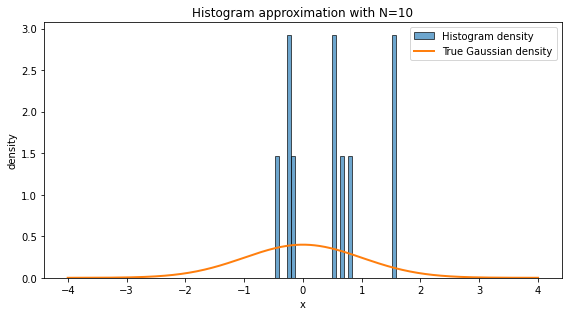

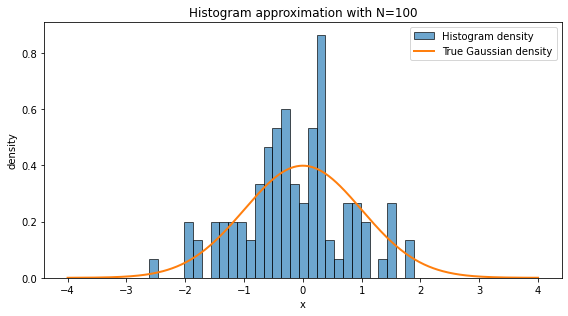

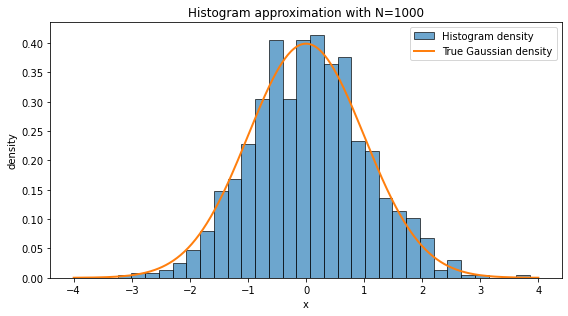

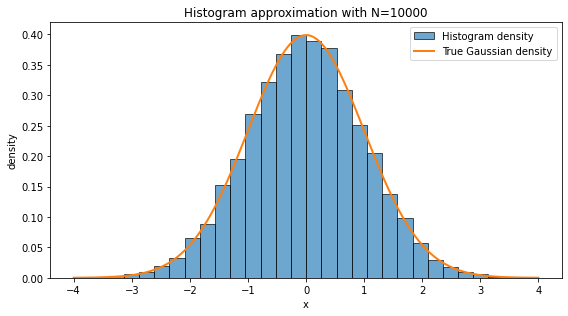

In [ ]:
np.random.seed(42) # For reproducibility

for N in [10, 100, 1000, 10000]:
    data = np.random.normal(loc=0, scale=1, size=N)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(data, bins=30, density=True, alpha=0.65, edgecolor="black", label="Histogram density")

    x = np.linspace(-4, 4, 500)
    ax.plot(x, norm.pdf(x, 0, 1), linewidth=2, label="True Gaussian density")

    ax.set_title(f"Histogram approximation with N={N}")
    ax.set_xlabel("x")
    ax.set_ylabel("density")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

### ❓ Exercise
**Q4.** Why does the histogram with $N=10$ look so different from the histogram with $N=10000$?


## <span style="color:maroon"> Surprise, entropy and gini impurity </span>

### Surprise (Self-Information)

Surprise is the measurement of how "unexpected" an event is. If an event is very probable, it should not surprise us much. If an event is very rare, it should surprise us a lot.


Mathematically for a event with probability $p$ it could have been $\frac{1}{p}$, but to allow "zero" surprise for certain event, the surprise (or self-information) is defined as  

$$
I(p)= -\log_2(p)
$$


This definition has three nice properties:

- if $p=1$, then $I(p)=0$: a certain event carries no surprise.
- if $p$ becomes smaller, $I(p)$ becomes larger;
- independent surprises add, because $-\log(pq)=-\log p-\log q$.

### Shannon entropy

- Entropy is the **average surprise** across all possible outcomes.
- For a random variable $X$ with outcomes $x_i$ and probabilities $p_i$, Shannon entropy is defined as

$$
S(X)=-\sum_i p_i\log_2(p_i)
$$

- Higher entropy --> more uncertainty; lower entropy --> less uncertainty

```{admonition} Example: Entropy of a Coin
:class: tip

For a coin, the two outcomes are

$$
X\in\{\text{Heads},\text{Tails}\}.
$$

Let

$$
P(\text{Heads})=p, \qquad P(\text{Tails})=1-p.
$$

Using the Shannon entropy formula,

$$
S(X)=-\sum_i p_i\log_2(p_i),
$$

we get

$$
S(X)=-p\log_2(p)-(1-p)\log_2(1-p).
$$

For a fair coin, $p=1/2$. Therefore,

$$
S(X)
=
-\frac{1}{2}\log_2\frac{1}{2}
-\frac{1}{2}\log_2\frac{1}{2}.
$$

Since $\log_2(1/2)=-1$,

$$
S(X)
=
-\frac{1}{2}(-1)-\frac{1}{2}(-1)
=
1.
$$

So a fair coin has entropy

$$
\boxed{S(X)=1\ \text{bit}}.
$$

For a deterministic coin,

$$
P(\text{Heads})=1, \qquad P(\text{Tails})=0.
$$

Hence,

$$
S(X)
=
-1\log_2(1)-0\log_2(0).
$$

Using $\log_2(1)=0$ and the convention $0\log_2(0)=0$,

$$
S(X)=0.
$$

So a deterministic coin has entropy

$$
\boxed{S(X)=0\ \text{bits}}.
$$
```


### Gini index

Shannon entropy is one way of measuring how mixed or uncertain a collection of class labels is. `Decision trees`, which we will learn in a minute, often use another closely related quantity called the **Gini impurity**.

For a dataset $D$ containing $C$ classes, let $p_i$ be the fraction of samples belonging to class $i$. The Gini impurity is

$$
G(D)=1-\sum_{i=1}^{C}p_i^2.
$$

One way to understand this formula is to imagine drawing two class labels independently according to the class proportions inside the node:

- $\sum_i p_i^2$ is the probability that the two labels are the same;
- $1-\sum_i p_i^2$ is the probability that the two labels are different.

Therefore, the Gini impurity is small when one class dominates and large when the classes are strongly mixed.

```{note}
Gini impurity and Shannon entropy are not numerically identical, but they usually agree on the basic question:

> Is a collection mostly pure, or does it contain a mixture of classes?
```

### ❓ Exercise

**Q5.** If all samples belong to the same class, what would be the Gini impurity $G_{\min}$?


For $C$ equally populated classes,

$$
p_i=\frac{1}{C},
$$

and therefore

$$
G_{\max}
=
1-C\left(\frac{1}{C}\right)^2
=
1-\frac{1}{C}.
$$

Thus, unlike a probability, the maximum Gini impurity is not always $1$. It depends on the number of classes.

For example:

- two equally populated classes: $G_{\max}=1/2$;
- four equally populated classes: $G_{\max}=3/4$;
- five equally populated classes: $G_{\max}=4/5$.

In comparison note the maxima of Shannon entropy is $S_{\max}=\log_2(C)$.

In [11]:
import math

def normalize_probabilities(probabilities):
    """Return a normalized probability vector and check that it is valid."""
    probs = np.asarray(probabilities, dtype=float)
    if np.any(probs < 0):
        raise ValueError("Probabilities must be non-negative.")
    total = probs.sum()
    if total <= 0:
        raise ValueError("At least one probability must be positive.")
    return probs / total

def calculate_surprise(probability):
    """Surprise of one event, measured in bits."""
    if probability == 0:
        return float('inf')
    return -math.log2(probability)

def calculate_entropy(probabilities):
    """Shannon entropy of a probability distribution, measured in bits."""
    probs = normalize_probabilities(probabilities)
    return float(-sum(p * math.log2(p) for p in probs if p > 0))

def calculate_gini(probabilities):
    """Gini impurity of a probability distribution."""
    probs = normalize_probabilities(probabilities)
    return float(1 - np.sum(probs**2))

def plot_distribution_metrics(probabilities, title="Distribution metrics", class_names=None):
    """Plot probability, surprise, entropy, and Gini in clear separate panels.

    This version avoids overlapping labels by using separate figures and explicit spacing.
    """
    probs = normalize_probabilities(probabilities)
    n = len(probs)
    if class_names is None:
        class_names = [f"Class {i+1}" for i in range(n)]

    entropy = calculate_entropy(probs)
    gini = calculate_gini(probs)
    surprises = np.array([calculate_surprise(p) for p in probs])

    # Figure 1: probability distribution
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(class_names, probs, edgecolor="black")
    ax.set_ylim(0, max(1.0, 1.15 * probs.max()))
    ax.set_ylabel("Probability")
    ax.set_title(title + "\nProbability distribution")
    ax.bar_label(bars, fmt="%.3f", padding=3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    # Figure 2: surprise values
    finite_surprises = surprises[np.isfinite(surprises)]
    cap = 1.0 if len(finite_surprises) == 0 else max(1.0, finite_surprises.max() + 1.0)
    plot_surprises = np.where(np.isfinite(surprises), surprises, cap)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(class_names, plot_surprises, edgecolor="black")
    ax.set_ylabel(r"Surprise, $-\log_2 p$")
    ax.set_title("Surprise of each event")
    for i, (bar, val) in enumerate(zip(bars, surprises)):
        label = r"$\infty$" if not np.isfinite(val) else f"{val:.2f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label,
                ha="center", va="bottom", fontsize=10)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    # Figure 3: summary impurity measures
    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    metric_names = ["Shannon entropy\n(bits)", "Gini impurity"]
    metric_values = [entropy, gini]
    bars = ax.bar(metric_names, metric_values, edgecolor="black")
    ax.set_title("Summary of uncertainty / impurity")
    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.set_ylim(0, max(1.0, 1.2 * max(metric_values)))
    plt.tight_layout()
    plt.show()

    # Figure 4: normalized summary of impurity measures
    # The raw Shannon entropy and Gini impurity use different numerical scales.
    # For C classes, their maximum possible values are:
    #
    #     H_max = log2(C)
    #     G_max = 1 - 1/C
    # Both maxima occur when all C classes are equally probable.
    # Dividing by these maxima puts both measures on the common range [0, 1].

    n_classes = len(probs)

    entropy_max = np.log2(n_classes)
    gini_max = 1.0 - 1.0 / n_classes

    normalized_entropy = (
        entropy / entropy_max
        if entropy_max > 0
        else 0.0
        )

    normalized_gini = (
        gini / gini_max
        if gini_max > 0
        else 0.0
        )

    fig, ax = plt.subplots(figsize=(6.5, 4.0))

    metric_names = [
        "Normalized Shannon entropy",
        "Normalized Gini impurity",
    ]

    metric_values = [
        normalized_entropy,
        normalized_gini,
    ]

    bars = ax.bar(
        metric_names,
        metric_values,
        edgecolor="black",
    )

    ax.set_title("Normalized summary of uncertainty / impurity")
    ax.set_ylabel("Normalized impurity")
    ax.set_ylim(0, 1.1)

    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=3,
    )

    plt.tight_layout()
    plt.show()


    print(f"Normalized probabilities: {np.round(probs, 4)}")
    print(f"Shannon entropy = {entropy:.4f} bits")
    print(f"Gini impurity   = {gini:.4f}")


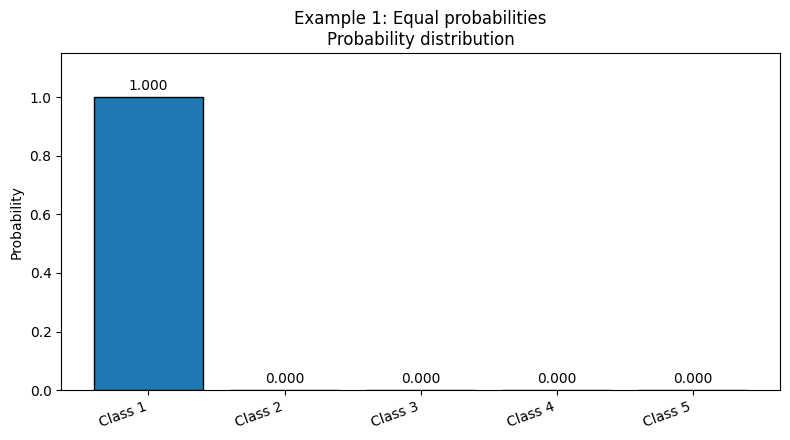

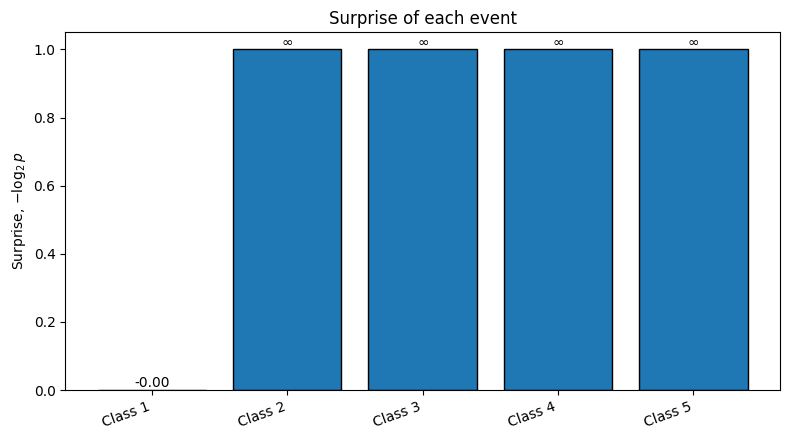

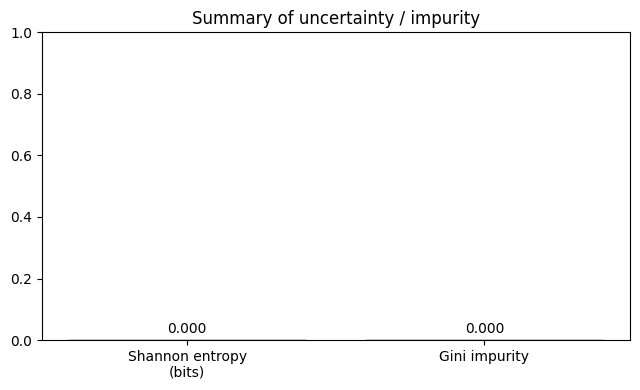

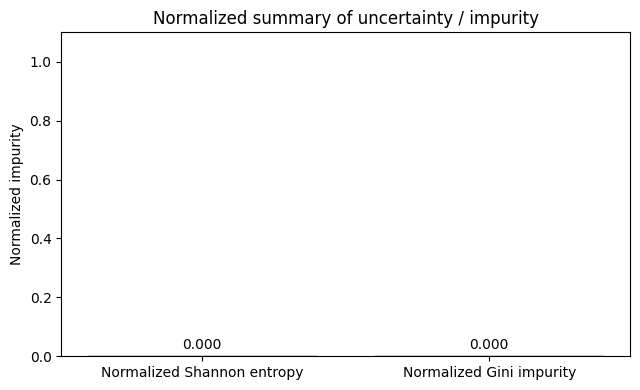

Normalized probabilities: [1. 0. 0. 0. 0.]
Shannon entropy = -0.0000 bits
Gini impurity   = 0.0000


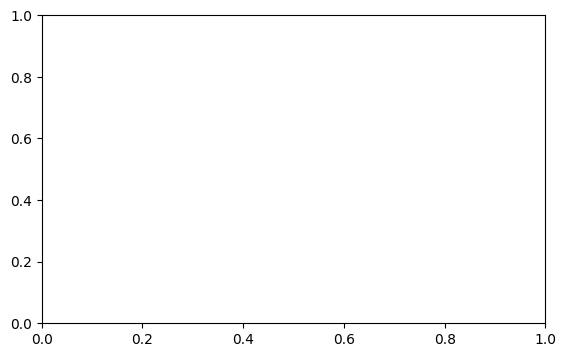

In [18]:
# Example 1: Equal probabilities.
# This is maximally uncertain for five classes.

probabilities_1 = [1, 0, 0, 0, 0]
plot_distribution_metrics(probabilities_1, title="Example 1: Equal probabilities")

fig, ax = plt.subplots(figsize=(6.5, 4.0))

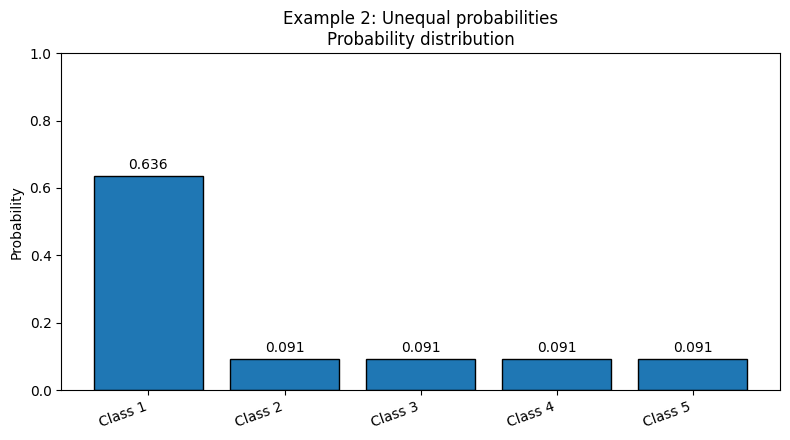

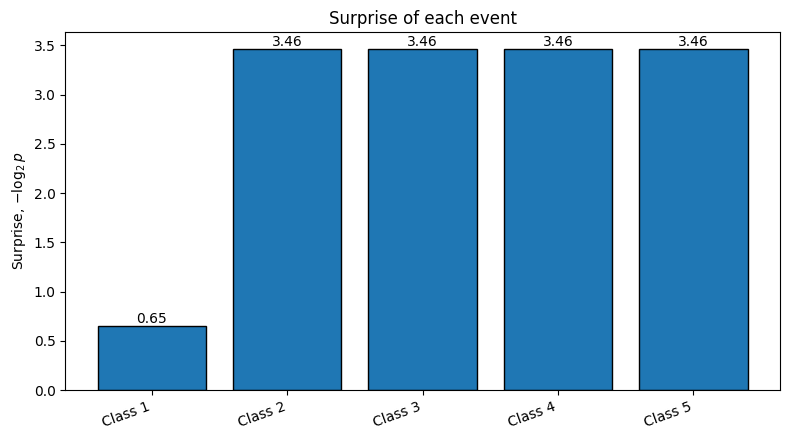

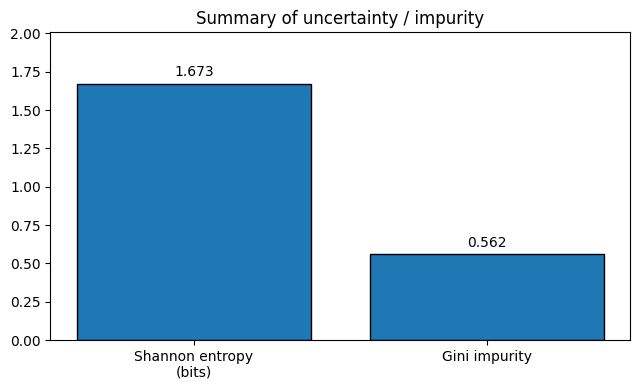

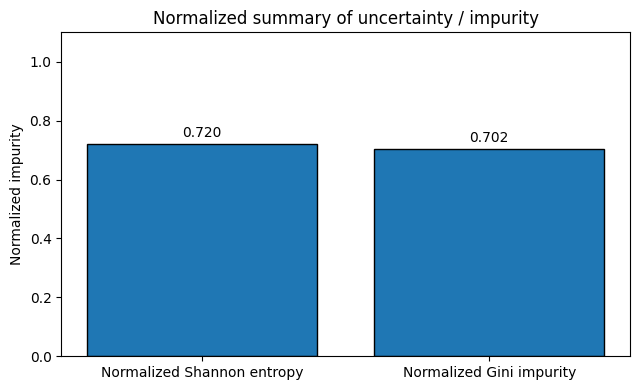

Normalized probabilities: [0.6364 0.0909 0.0909 0.0909 0.0909]
Shannon entropy = 1.6729 bits
Gini impurity   = 0.5620


In [13]:
# Example 2: Unequal probabilities.
# One class dominates, so uncertainty is lower.

probabilities_2 = [0.7, 0.1, 0.1, 0.1, 0.1]
plot_distribution_metrics(probabilities_2, title="Example 2: Unequal probabilities")

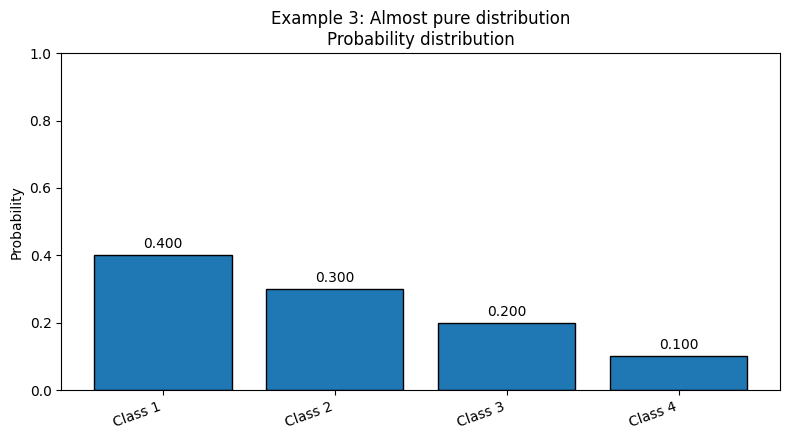

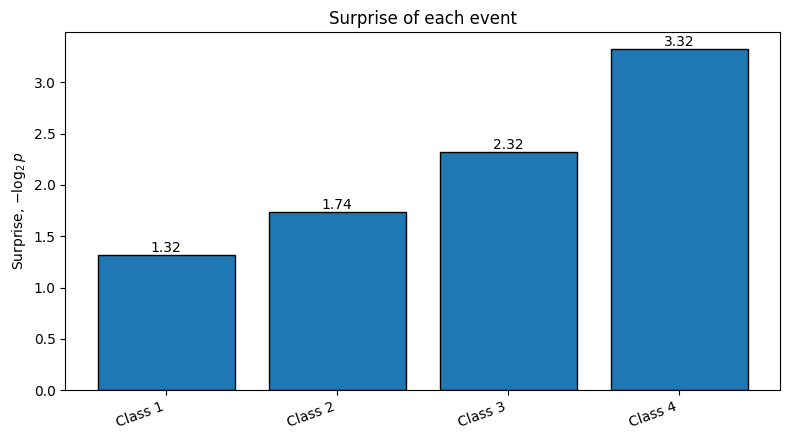

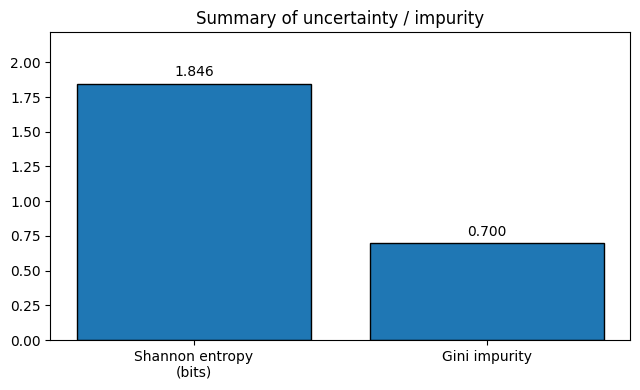

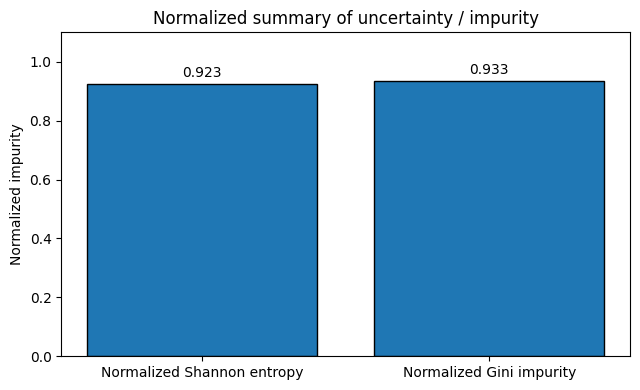

Normalized probabilities: [0.4 0.3 0.2 0.1]
Shannon entropy = 1.8464 bits
Gini impurity   = 0.7000


In [14]:
# Example 3: Almost pure distribution.
# The first class is almost certain; the zero-probability events have infinite surprise,
# but they do not contribute to entropy because p log(p) tends to zero as p -> 0.

probabilities_3 = [0.4, 0.3, 0.2, 0.1]
plot_distribution_metrics(probabilities_3, title="Example 3: Almost pure distribution")

### ❓ Exercise

**Q6.** For different situations that you can think of, do a quantitative analysis of Gini index vs Shannon entropy.

Try at least these four probability distributions:

1. $\left[1,0,0,0\right]$ : perfectly pure.
2. $\left[0.7,0.1,0.1,0.1\right]$ : one dominant class.
3. $\left[0.4,0.3,0.2,0.1\right]$ : moderately mixed.
4. $\left[0.25,0.25,0.25,0.25\right]$ : maximally mixed for four classes.
